In [2]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '/mnt/e/fyassine/ad-early-detection')
import config

### DATA LOADING

In [3]:
from import_utils import load_and_process_cohorts, find_missing_ids

correlation_type = "xcorr"
print(f'CORRELATION METRIC: {correlation_type} \n')
cohorts = load_and_process_cohorts(config, correlation_type=correlation_type)

patient_df = pd.read_csv(config.DELCODE_PATIENT_DATA)
missing_ids = find_missing_ids(patient_df, cohorts)
print(f"\n{len(missing_ids)} IDs ARE IN THE CSV BUT NOT IN THE DATA!")

CORRELATION METRIC: xcorr 

Healthy: 201 subjects, Matrix shape: (201, 110, 110), Edges shape: (201, 5995)
AD: 104 subjects, Matrix shape: (104, 110, 110), Edges shape: (104, 5995)
MCI: 533 subjects, Matrix shape: (533, 110, 110), Edges shape: (533, 5995)
Converters: 60 subjects, Matrix shape: (60, 110, 110), Edges shape: (60, 5995)

98 IDs ARE IN THE CSV BUT NOT IN THE DATA!


### ANALYZE PAIRWISE

Starting Batch Diagnostic Tests...


=== DIAGNOSTIC REPORT: Converters vs AD ===
Sample Sizes: Converters=60, AD=104
Avg Edge SD: Converters=0.071, AD=0.073
Signal: 0 edges survive FDR (0.0%)
Effect Size: Median |d|=0.116, Edges >0.5=0.3%


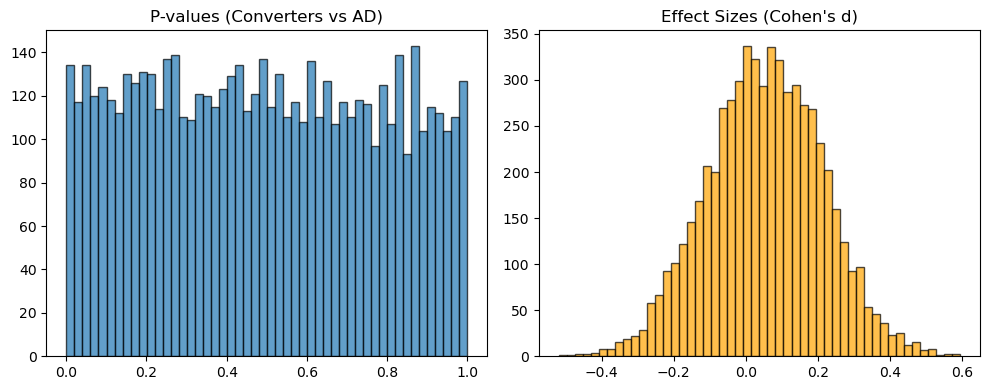


=== DIAGNOSTIC REPORT: Converters vs MCI ===
Sample Sizes: Converters=60, MCI=533
Avg Edge SD: Converters=0.071, MCI=0.075
Signal: 0 edges survive FDR (0.0%)
Effect Size: Median |d|=0.106, Edges >0.5=0.2%


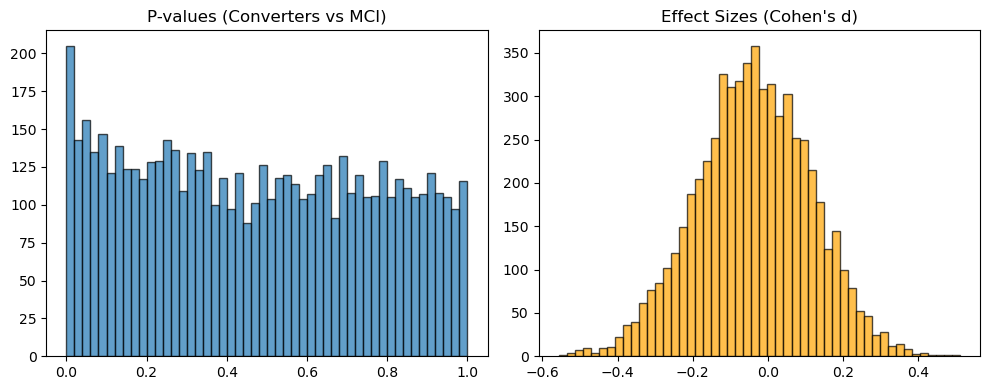


=== DIAGNOSTIC REPORT: Healthy vs MCI ===
Sample Sizes: Healthy=201, MCI=533
Avg Edge SD: Healthy=0.074, MCI=0.075
Signal: 1 edges survive FDR (0.0%)
Effect Size: Median |d|=0.066, Edges >0.5=0.0%


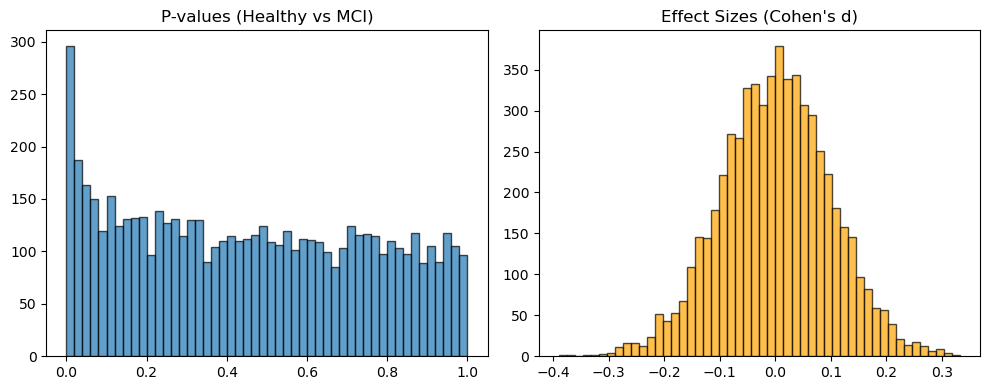


=== DIAGNOSTIC REPORT: Healthy vs Converters ===
Sample Sizes: Healthy=201, Converters=60
Avg Edge SD: Healthy=0.074, Converters=0.071
Signal: 7 edges survive FDR (0.1%)
Effect Size: Median |d|=0.128, Edges >0.5=1.0%


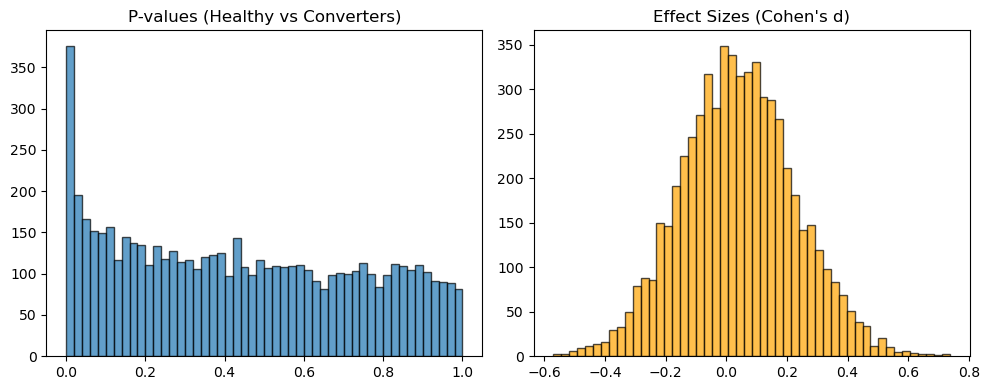


=== DIAGNOSTIC REPORT: Healthy vs AD ===
Sample Sizes: Healthy=201, AD=104
Avg Edge SD: Healthy=0.074, AD=0.073
Signal: 274 edges survive FDR (4.6%)
Effect Size: Median |d|=0.111, Edges >0.5=1.5%


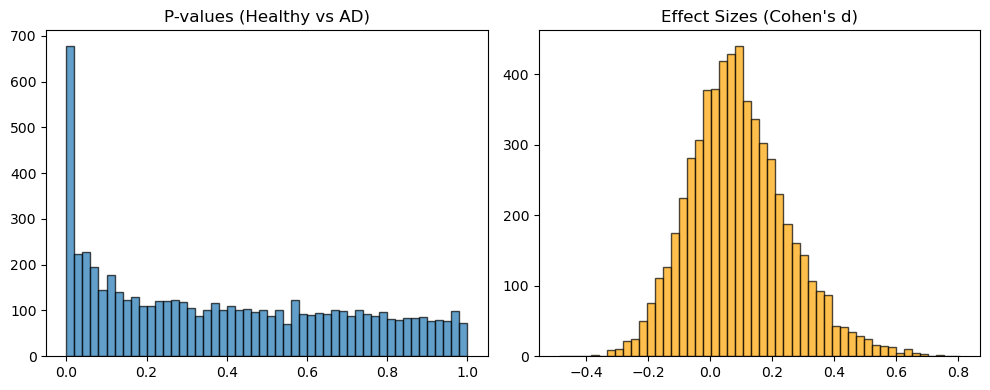


FINAL MACHINE LEARNING RISK ASSESSMENT
PAIR                      | STATUS     | FDR EDGES  | FLAGS
--------------------------------------------------------------------------------
[!] Converters vs AD      | HIGH RISK  | 0          | CRITICAL: No Signal (0 FDR edges); Warning: Tiny Effects (Few edges > 0.5)
[!] Converters vs MCI     | HIGH RISK  | 0          | CRITICAL: No Signal (0 FDR edges); Warning: Tiny Effects (Few edges > 0.5)
[~] Healthy vs MCI        | CAUTION    | 1          | Warning: Weak Signal (<1% FDR edges); Warning: Tiny Effects (Few edges > 0.5)
[~] Healthy vs Converters | CAUTION    | 7          | Warning: Weak Signal (<1% FDR edges)
[✓] Healthy vs AD         | SAFE       | 274        | None
--------------------------------------------------------------------------------
Guide:
  HIGH RISK: Model will likely overfit or fail completely.
  CAUTION:   Model needs careful feature selection (e.g., top 1-5% features).
  SAFE:      Data has strong signal; standard ML appro

In [4]:
from edges_utils_basic import run_batch_diagnostics

comparisons = [
    ('converter', 'ad'),
    ('converter', 'mci'),
    ('healthy', 'mci'),
    ('healthy', 'converter'),
    ('healthy', 'ad')
]

run_batch_diagnostics(cohorts, comparisons)

COMPREHENSIVE NETWORK ANALYSIS FOR BRAIN CONNECTIVITY

PAIRWISE COMPARISON MODE
Analyzing 2 groups:
  • Converters (n=60)
  • AD (n=104)

This analysis includes TWO complementary tests:

  1. PERMANOVA (Permutational MANOVA)
     → Tests if groups differ in OVERALL connectivity
     → Does NOT assume edge independence
     → Omnibus test: 'Are groups different?'

  2. Network-Based Statistic (NBS)
     → Identifies WHICH subnetworks differ
     → More powerful than edge-by-edge correction
     → Localization: 'WHERE are they different?'

  INTERPRETATION GUIDE:
  ┌─────────────────┬──────────────┬─────────────────────────┐
  │  PERMANOVA      │     NBS      │    Interpretation       │
  ├─────────────────┼──────────────┼─────────────────────────┤
  │  Significant    │  Significant │ ✓ Clear network effects │
  │  Significant    │  Not sig.    │ ~ Diffuse differences   │
  │  Not sig.       │  Significant │ ⚠ Recheck (unlikely)    │
  │  Not sig.       │  Not sig.    │ ✗ No group differ

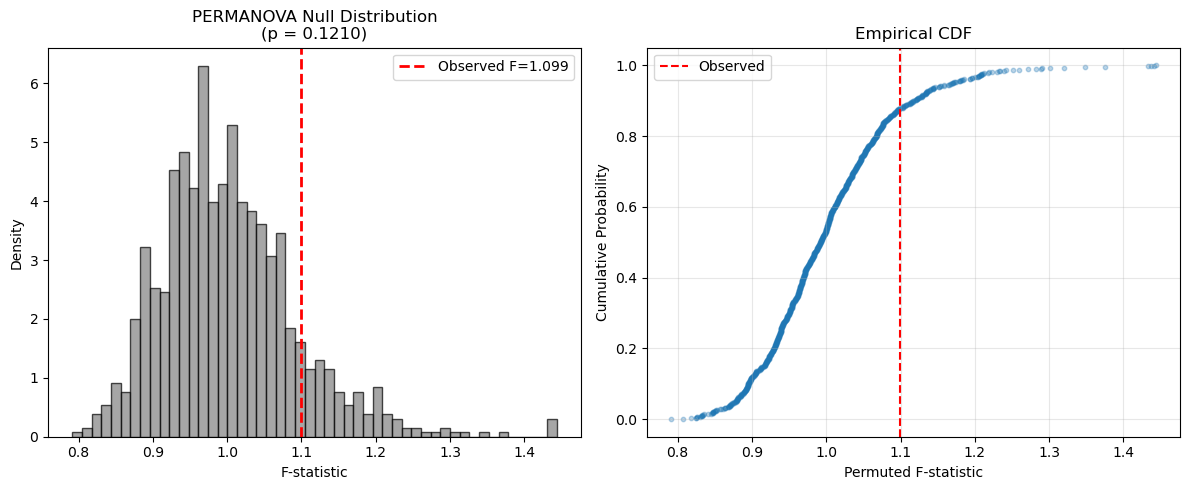


▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶
STEP 2: Network-Based Statistic (Localization)
▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶
NETWORK-BASED STATISTIC (NBS) - FAST VERSION

WHAT THIS TEST DOES:
  The NBS identifies CONNECTED SUBNETWORKS (not individual edges)
  that differ between groups. It's like cluster-based thresholding
  but for network data instead of brain images.

  How it works:
    1. Tests each edge independently (t-test)
    2. Keeps edges above threshold (forms suprathreshold network)
    3. Finds connected components in this network
    4. Uses permutation testing to assess significance

  Key Advantage: More powerful than edge-by-edge FDR correction
                 when brain changes form connected networks

  Key Limitation: Only provides WEAK FWE control
                  (can't declare individual edges significant,
                  only entire components)

THRESHOLD SELECTION GUIDE:
  t = 2.5 → Liberal (exploratory, finds more but riskier)
  t = 3.0 → Moderate (RECOMMENDE

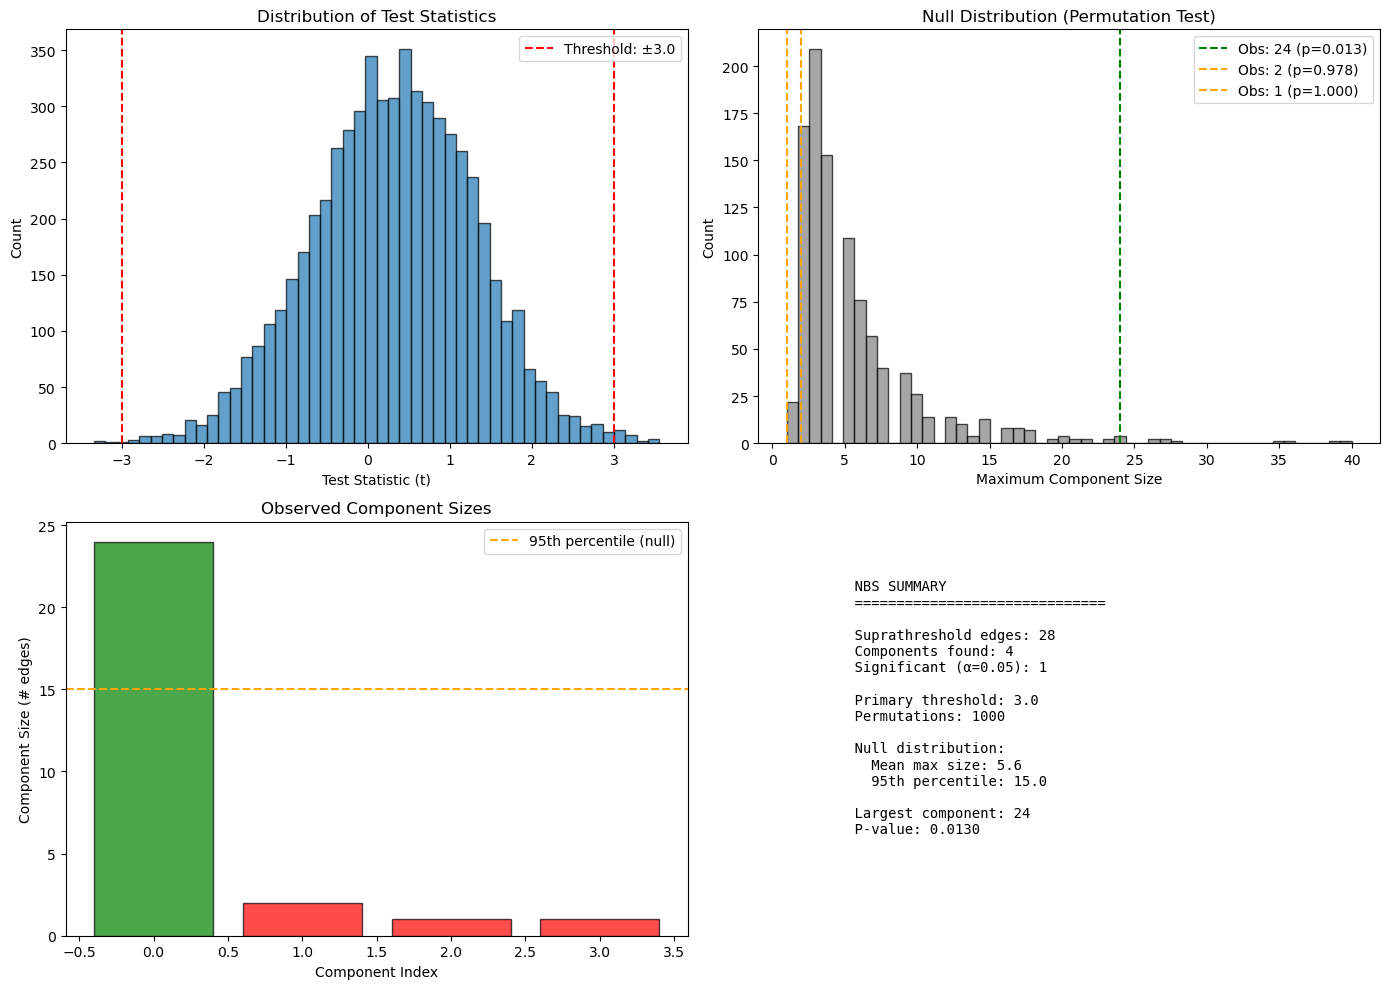


COMBINED INTERPRETATION

PERMANOVA: ✗ NOT SIGNIFICANT
           (p = 0.1210, R² = 0.007)

NBS:       ✓ SIGNIFICANT
           (1 component(s) found)

----------------------------------------------------------------------
⚠ UNEXPECTED RESULT:
   NBS found components but PERMANOVA is not significant.
   This is unusual and warrants careful inspection.

   Possible issues:
   • False positive in NBS (check p-values carefully)
   • Small sample size causing instability
   • Consider increasing permutations

   → Interpret with caution
   → Validate in independent dataset



In [5]:
from edges_utils_advanced import run_network_analysis

# Compare healthy vs ad
results = run_network_analysis(
    cohorts,
    group_a='converter',
    group_b='ad',
    n_perms=1000
)

In [6]:
from interpretation_utils import view_significant_edges, roi_labels

print(f"Total ROI Labels: {len(roi_labels)}")
assert len(roi_labels) == 110, "Error: List must have exactly 110 regions!"

df_edges = view_significant_edges(results, roi_names=roi_labels)

display(df_edges)

Total ROI Labels: 110
--- ANATOMY OF COMPONENT 1 (24 edges) ---
P-value: 0.0130


,Region A,Region B,T-Statistic,Abs(T-Stat)
0,L_Postcentral_Gyrus,R_Cingulate_Gyrus_posterior,3.551928,3.551928
1,L_Postcentral_Gyrus,R_Temporal_Occipital_Fusiform_Cortex,3.533744,3.533744
2,L_Planum_Polare,L_Putamen,3.473432,3.473432
3,L_Precentral_Gyrus,L_Putamen,3.408245,3.408245
4,R_Inferior_Temporal_Gyrus_anterior,R_Juxtapositional_Lobule_SMA,3.400264,3.400264
5,L_Thalamus,R_Cingulate_Gyrus_posterior,-3.335256,3.335256
6,L_Putamen,R_Temporal_Occipital_Fusiform_Cortex,3.262173,3.262173
7,L_Putamen,L_Accumbens,3.207509,3.207509
8,L_Occipital_Fusiform_Gyrus,L_Putamen,3.206785,3.206785
9,R_Middle_Temporal_Gyrus_posterior,R_Inferior_Temporal_Gyrus_temporooccipital,3.174611,3.174611


### ANALYZE ALL COHORTS

COMPREHENSIVE NETWORK ANALYSIS FOR BRAIN CONNECTIVITY


▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶
STEP 1: PERMANOVA (Omnibus Test)
▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶

PERMANOVA (Permutational MANOVA)

WHAT THIS TEST DOES:
  PERMANOVA tests whether groups differ in their OVERALL
  connectivity patterns using multivariate distances.

  How it works:
    1. Treats each subject as a point in high-dimensional space
    2. Calculates distances between all subject pairs
    3. Tests if within-group distances < between-group distances
    4. Uses permutation to assess significance

  KEY ADVANTAGES:
    ✓ Does NOT assume edges are independent
      (Perfect for brain networks with correlated connections!)
    ✓ Does NOT assume multivariate normality
    ✓ Captures overall group differences (not just univariate)
    ✓ Provides R² effect size (% variance explained)

  WHAT IT TELLS YOU:
    Significant result → Groups have different connectivity patterns
    Non-significant → Groups are similar in co

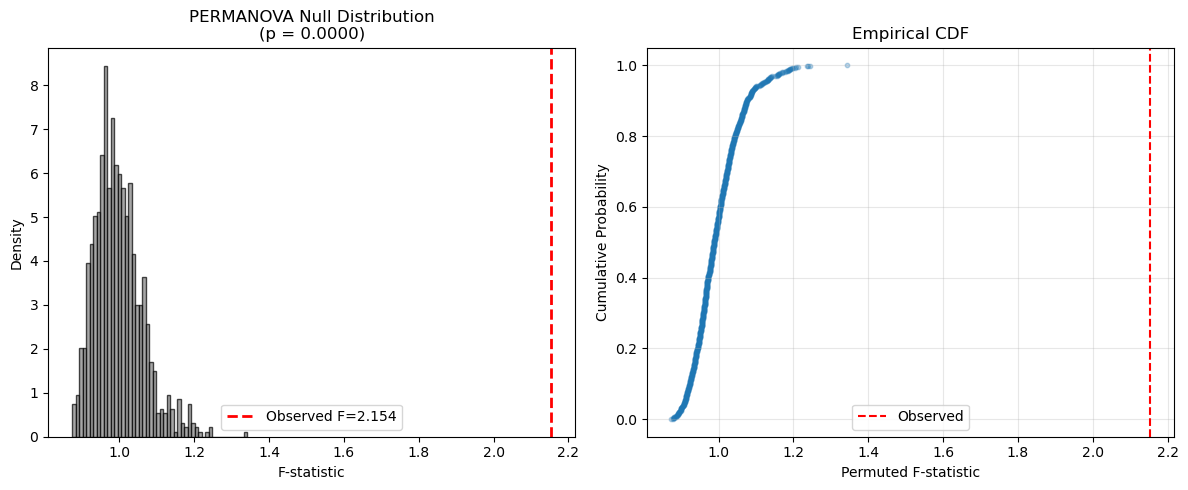


NEXT STEPS FOR MULTI-GROUP ANALYSIS

✓ PERMANOVA is SIGNIFICANT
  (p = 0.0000, R² = 0.007)

  At least one group differs from the others.

  RECOMMENDED FOLLOW-UP:
  → Run PAIRWISE comparisons to identify which groups differ

  Example code:
  ```python
  # Compare healthy vs ad
  results = run_network_analysis(
      cohorts,
      group_a='healthy',
      group_b='ad',
      n_perms=5000
  )

  # Compare healthy vs mci
  results = run_network_analysis(
      cohorts,
      group_a='healthy',
      group_b='mci',
      n_perms=5000
  )

  # Compare healthy vs converter
  results = run_network_analysis(
      cohorts,
      group_a='healthy',
      group_b='converter',
      n_perms=5000
  )

  # Compare ad vs mci
  results = run_network_analysis(
      cohorts,
      group_a='ad',
      group_b='mci',
      n_perms=5000
  )

  # Compare ad vs converter
  results = run_network_analysis(
      cohorts,
      group_a='ad',
      group_b='converter',
      n_perms=5000
  )

  # Compare m

In [7]:
from edges_utils_advanced import run_network_analysis

results = run_network_analysis(
    cohorts,
    n_perms=1000,
    run_nbs=False  #
)

In [8]:
from viz_utils import visualize_nbs_network, visualize_nbs_circular

print(results.keys())
nbs_results = results['nbs']
sig_component = results['nbs']['significant_components'][0]
edge_indices = sig_component['edges']

viz_results = visualize_nbs_network(
    nbs_results,
    cohorts={'mci': cohorts['mci'], 'ad': cohorts['ad']},
    group_a='mci',
    group_b='ad',
    component_idx=0,  # First (largest) component
    node_names=None,  # Use this if you have region names
    figsize=(20, 12)
)

# If you have many nodes (>50), use circular view instead
visualize_nbs_circular(
    nbs_results,
    cohorts={'mci': cohorts['mci'], 'ad': cohorts['ad']},
    group_a='mci',
    group_b='ad',
    component_idx=0,
    node_names=None,
    figsize=(15, 15)
)

dict_keys(['permanova'])


KeyError: 'nbs'

### AGE REGRESSED

In [ ]:
from age_utils import load_subject_ages

age_map = load_subject_ages()

In [ ]:
from age_utils import get_aligned_ages, regress_out_covariate_mean_projections

for group_name, group_data in cohorts.items():
    print(f"\nProcessing Age Regression for group:"f" {group_name}")
    ids = group_data['ids']
    edges = group_data['edges']

    ages = get_aligned_ages(ids, age_map)
    # 'valid_mask' tells us which subjects survived (had valid ages)
    residuals, valid_mask = regress_out_covariate_mean_projections(edges, ages)
    cohorts[group_name]['edges'] = residuals
    cohorts[group_name]['ids'] = [pid for i, pid in enumerate(ids) if valid_mask[i]]
    cohorts[group_name]['ages'] = ages[valid_mask]

    print(f"  -> Original size: {len(ids)}, New size: {len(cohorts[group_name]['ids'])}")

print("\nDone. 'cohorts' now contains age-corrected connectivity residuals.")

In [ ]:
from edges_utils_basic import run_batch_diagnostics

comparisons = [
    ('converter', 'ad'),
]

run_batch_diagnostics(cohorts, comparisons)

In [ ]:
from edges_utils_advanced import run_network_analysis

# Compare healthy vs ad
results = run_network_analysis(
    cohorts,
    group_a='mci',
    group_b='converter',
    n_perms=1000
)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import config  # Assumes you have your config file ready
import import_utils
import age_utils
import edges_utils_advanced

# === PARAMETERS ===
METRICS = ['pearson', 'spearman', 'kendall', 'riemannian', 'xcorr']
PAIRS_TO_TEST = [('healthy', 'ad'), ('mci', 'converter')]
ALPHA = 0.05

def run_grand_analysis():
    summary_data = []

    # 1. Load Ages once (metadata is constant)
    print("Loading Age Data...")
    age_map = age_utils.load_subject_ages()

    for metric in tqdm(METRICS, desc="Analyzing Metrics"):
        print(f"\n\n{'='*40}\nPROCESSING METRIC: {metric.upper()}\n{'='*40}")

        # --- LOAD COHORTS ---
        try:
            # Check if files exist implicitly by trying to load
            cohorts = import_utils.load_and_process_cohorts(config, correlation_type=metric)
            if not cohorts:
                print(f"Skipping {metric} (No data found)")
                continue
        except Exception as e:
            print(f"Skipping {metric}: {e}")
            continue

        # --- PREPARE REGRESSION DATA (ALL SUBJECTS) ---
        # We combine all subjects to fit a robust Age model
        all_ids = []
        all_edges = []
        subj_indices = {} # To map back to cohorts

        current_idx = 0
        for group_name, data in cohorts.items():
            n_subs = len(data['ids'])
            all_ids.extend(data['ids'])
            all_edges.append(data['edges'])
            subj_indices[group_name] = slice(current_idx, current_idx + n_subs)
            current_idx += n_subs

        all_edges = np.vstack(all_edges)

        # Align Ages
        all_ages = age_utils.get_aligned_ages(all_ids, age_map)

        # Regress Age (Fit on valid subjects only)
        # Note: We use the function from age_utils but we must be careful with the mask
        print(f"  Regressing Age for {metric}...")
        residuals, valid_mask = age_utils.regress_out_covariate(all_edges, all_ages)

        # Re-distribute residuals back to cohorts
        cohorts_regressed = {}

        # We need to map the 'valid_mask' back to the original indices
        # This is tricky because 'residuals' is smaller than 'all_edges' if subjects were dropped
        # Let's reconstruct the cohort structure

        current_valid_idx = 0
        full_mask_pos = 0

        for group_name in cohorts.keys():
            original_slice = subj_indices[group_name]
            group_mask = valid_mask[original_slice] # True/False for this group
            n_valid_group = np.sum(group_mask)

            # Extract the subset of residuals belonging to this group
            group_residuals = residuals[current_valid_idx : current_valid_idx + n_valid_group]

            # Create new cohort entry
            cohorts_regressed[group_name] = {
                'edges': group_residuals,
                'ids': np.array(cohorts[group_name]['ids'])[group_mask]
            }
            current_valid_idx += n_valid_group

        # --- RUN TESTS (Raw vs Regressed) ---
        for g1, g2 in PAIRS_TO_TEST:
            pair_label = f"{g1} vs {g2}"

            # Test 1: RAW
            print(f"  Testing RAW: {pair_label}")
            perm_raw = edges_utils_advanced.permanova(cohorts, g1, g2, n_permutations=500)

            # Test 2: REGRESSED
            print(f"  Testing REGRESSED: {pair_label}")
            perm_reg = edges_utils_advanced.permanova(cohorts_regressed, g1, g2, n_permutations=500)

            # Test 3: NBS (Regressed Only - usually most relevant)
            # We use a quick t=3.0 threshold
            nbs_res = edges_utils_advanced.network_based_statistic(
                cohorts_regressed, g1, g2, primary_threshold=3.0, n_permutations=200
            )
            n_comps = len(nbs_res.get('significant_components', []))

            summary_data.append({
                'Metric': metric,
                'Pair': pair_label,
                'Raw_R2': perm_raw['r_squared'],
                'Raw_P': perm_raw['p_value'],
                'Reg_R2': perm_reg['r_squared'],
                'Reg_P': perm_reg['p_value'],
                'NBS_Comps': n_comps,
                'Gain_R2': perm_reg['r_squared'] - perm_raw['r_squared']
            })

    # --- VISUALIZE RESULTS ---
    df_results = pd.DataFrame(summary_data)

    if not df_results.empty:
        print("\n\n" + "="*60)
        print("FINAL COMPARISON RESULTS")
        print("="*60)
        display(df_results.style.background_gradient(subset=['Reg_R2', 'Gain_R2'], cmap='viridis'))

        # Plot
        plt.figure(figsize=(12, 6))
        sns.barplot(data=df_results, x='Metric', y='Reg_R2', hue='Pair')
        plt.title("Sensitivity Comparison: Effect Size (R²) by Metric after Age Correction")
        plt.ylabel("Variance Explained (R²)")
        plt.xticks(rotation=45)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig("metric_comparison.png")
        plt.show()

    return df_results

# Run it
df_comparison = run_grand_analysis()